<a href="https://colab.research.google.com/github/joseflix/DocenciaUAB/blob/master/MN1/2025-2026/Practiques/Pr4_TLC_(solucions).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pràctica 4: El Teorema del Límit Central (TLC) en Acció**

**Objectiu de la pràctica**

En aquesta pràctica comprovarem experimentalment el **Teorema del Límit Central (TLC)**. Aquest teorema ens diu que la suma (o la mitjana) d'un nombre suficient de variables aleatòries independents i idènticament distribuïdes (i.i.d.) s'aproxima a una distribució Normal, **independentment de la distribució original d'aquestes variables**.

Per entendre-ho bé, primer ens familiaritzarem amb dues distribucions que no tenen forma de campana de Gauss: la **Uniforme** i la de **Poisson**.

**1. Distribució Uniforme (Contínua):**
Tots els valors dins d'un interval $[a, b]$ tenen la mateixa probabilitat de sortir.
Pots obtenir valors amb `scipy.stats.uniform.rvs(loc=a, scale=b-a, size=N)`.

**2. Distribució de Poisson (Discreta):**
Mesura el nombre de vegades que ocorre un esdeveniment en un interval de temps (ex: trucades a un call-center). Té un paràmetre $\lambda$ (lambda).
Pots obtenir valors amb `scipy.stats.poisson.rvs(mu=lambda, size=N)`.

### <font color='orange'>**> Python #1**</font>

Genera 1000 mostres individuals ($N=1$) per a una distribució uniforme a l'interval [0, 10]. Fes un histograma normalitzat dels resultats i mostra per pantalla el valor mig de la mostra i la variança, i compara amb els teòrics:
* Mitjana teòrica: $(a+b)/2$ = 5
* Variança teòrica: $(b-a)^2 / 12$ = 8.33

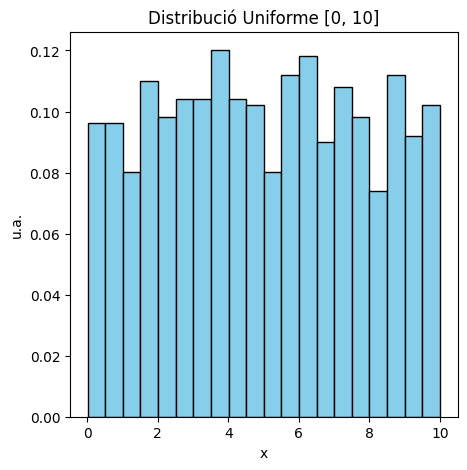

--- DISTRIBUCIÓ UNIFORME [0, 10] ---
Mitjana mostral:  5.00 (Valor teòric: 5.00)
Variança mostral: 8.13 (Valor teòric: 8.33)



In [ ]:
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt

# Mostra de Distribució Uniforme [0, 10]
dades_uni = ss.uniform.rvs(loc=0, scale=10, size=1000)

plt.figure(figsize=(5, 5))
plt.hist(dades_uni, bins=20, density=True, color='skyblue', edgecolor='black')
plt.title("Distribució Uniforme [0, 10]")
plt.xlabel('x')
plt.ylabel('u.a.')
plt.show()

mitjana_uni = np.mean(dades_uni)
varianca_uni = np.var(dades_uni)

print("--- DISTRIBUCIÓ UNIFORME [0, 10] ---")
print(f"Mitjana mostral:  {mitjana_uni:.2f} (Valor teòric: 5.00)")
print(f"Variança mostral: {varianca_uni:.2f} (Valor teòric: 8.33)")
print()

### <font color='orange'>**> Python #2**</font>

Genera 1000 mostres individuals ($N=1$) per a una distribució de Poisson amb $\lambda=2$. Fes un histograma normalitzat dels resultats i mostra per pantalla el valor mig de la mostra i la variança, i compara amb els teòrics:
* Mitjana teòrica: $\lambda$ = 2
* Variança teòrica: $\lambda$ = 2

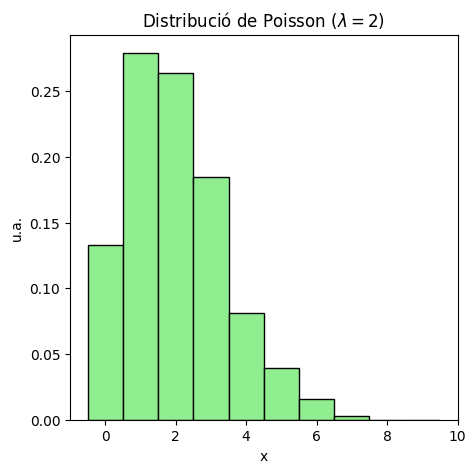

--- DISTRIBUCIÓ DE POISSON (lambda=2) ---
Mitjana mostral:  2.00 (Valor teòric: 2.00)
Variança mostral: 2.00 (Valor teòric: 2.00)


In [ ]:
# Mostra de Distribució de Poisson (lambda=2)
dades_pois = ss.poisson.rvs(mu=2, size=1000)

plt.figure(figsize=(5, 5))
plt.hist(dades_pois, bins=10, range=[-0.5,9.5], density=True, color='lightgreen', edgecolor='black')
plt.title(r"Distribució de Poisson ($\lambda=2$)")
plt.xlabel('x')
plt.ylabel('u.a.')
plt.show()

mitjana_pois = np.mean(dades_pois)
varianca_pois = np.var(dades_pois)

print("--- DISTRIBUCIÓ DE POISSON (lambda=2) ---")
print(f"Mitjana mostral:  {mitjana_pois:.2f} (Valor teòric: 2.00)")
print(f"Variança mostral: {varianca_pois:.2f} (Valor teòric: 2.00)")

### <font color='orange'>**> Python #3**</font>

Recordatori de l'equació de la mitjana mostral per a cada experiment:
$$
\bar{x} = \frac{1}{N} \sum_{i=1}^N r_i
$$
El TLC ens diu que si $N$ és gran, la distribució de les mitjanes $\bar{x}$ serà una Normal amb mitjana $\mu_{\bar{x}} = \mu$ i desviació estàndard $\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}}$, on $\mu$ i $\sigma$ són la mitjana i desviació de la distribució original.

Fes una funció anomenada *tlc\_uniforme* que retorni 1000 mostres de la mitja de $N$ valors obtinguts de la distribució **Uniforme** que has fet a l'apartat 1. És a dir, el primer element serà la mitja de N valors, el segon la mitja d'uns altres N valors, etc... fins a arribar a 1000 valors.

La funció la pots fer que accepti tant el màxim 1000 con N com a paràmetres:

```
def tlc_uniforme(Nmax, N)
```

Executa la funció i imprimeix per pantalla el valor mig i la desviació estàndard d'aquesta mostra. Fixeu-vos que el valor mig coincideix amb l'apartat 1, però no així la variança! (de fet si N=1, si que és igual)...


In [ ]:
def tlc_uniforme(Nmax, N):
  mitjanes_uni = []

  for _ in range(Nmax):
      mostra = ss.uniform.rvs(loc=0, scale=10, size=N)
      mitjanes_uni.append(np.mean(mostra))
  return mitjanes_uni

Nmax = 1000
N = 30

mitjanes_uni = tlc_uniforme(Nmax, N)

mitjana = np.mean(mitjanes_uni)
varianca = np.var(mitjanes_uni)

print("--- DISTRIBUCIÓ UNIFORME [0, 10], Nmax=", Nmax, ", N=", N, "---")
print(f"Mitjana mostral:  {mitjana:.2f}")
print(f"Variança mostral: {varianca:.2f}")

--- DISTRIBUCIÓ UNIFORME [0, 10], Nmax= 1000 , N= 30 ---
Mitjana mostral:  5.01
Variança mostral: 0.30


A classe veurem quina pinta tenen aquestes distribucions quan N$\neq$1... ;)

### <font color='green'>**> ENTREGA**</font>


1) Fes servir la funció de l'apartat 3, genera la llista de 1000 valors amb N=30, i fes un histograma normalitzat dels valors. Superposa sobre l'histograma la funció de densitat de probabilitat (pdf) de la distribució Normal teòrica esperada. **[3 punts]**

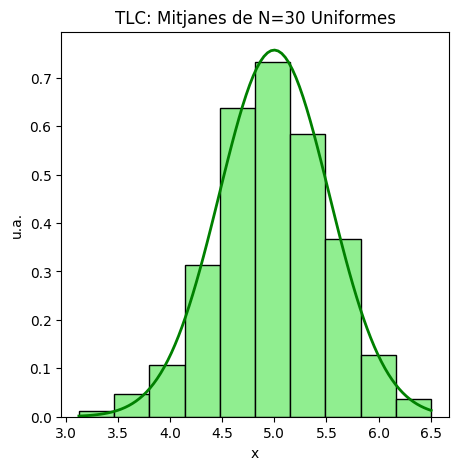

In [ ]:
Nmax=1000
N=30

mitjanes_uni = tlc_uniforme(Nmax, N)

plt.figure(figsize=(5, 5))
plt.hist(mitjanes_uni, bins=10, density=True, color='lightgreen', edgecolor='black')
plt.title(f"TLC: Mitjanes de N={N:.0f} Uniformes")
plt.xlabel('x')
plt.ylabel('u.a.')

mu_teorica = 5
var_uniforme = (10**2) / 12
sigma_teorica = np.sqrt(var_uniforme / N)

x = np.linspace(min(mitjanes_uni), max(mitjanes_uni), 100)
plt.plot(x, ss.norm.pdf(x, loc=mu_teorica, scale=sigma_teorica), 'g-', lw=2, label='Normal Teòrica')

plt.show()

2) Ara farem el mateix amb la distribució de **Poisson** amb $\lambda=2$. Com heu vist a la prèvia, aquesta distribució discreta està esbiaixada cap a l'esquerra.
Per a la Poisson, la mitjana teòrica és $\mu = \lambda$ i la variància també és $\sigma^2 = \lambda$.

*   Fes una nova funció, similar a la que has fet abans, però ara per a la Poisson:

```
def tlc_poisson(Nmax, N)
```

*   Fes el mateix que a l'apartat anterior, dibuixa la distribució que obtens en aquest cas per a Nmax=1000 i N=30 i superposa la funció de densitat de probabilitat (pdf) de la distribució Normal teòrica esperada. **[3 punts]**

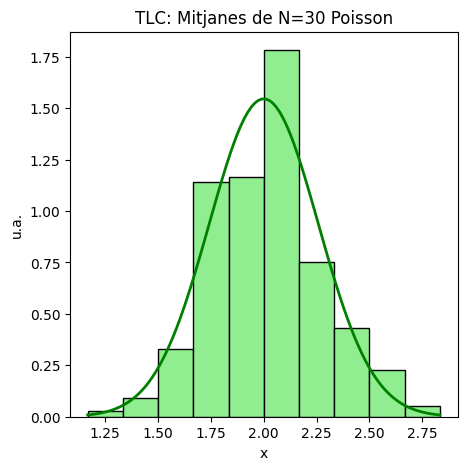

In [ ]:
Nmax=1000
N=30

def tlc_poisson(Nmax, N):
  mitjanes_poi = []

  for _ in range(Nmax):
      mostra = ss.poisson.rvs(mu=2, size=N)
      mitjanes_poi.append(np.mean(mostra))
  return mitjanes_poi

mitjanes_p = tlc_poisson(Nmax, N)

plt.figure(figsize=(5, 5))
plt.hist(mitjanes_p, bins=10, density=True, color='lightgreen', edgecolor='black')
plt.title(f"TLC: Mitjanes de N={N:.0f} Poisson")
plt.xlabel('x')
plt.ylabel('u.a.')

lmbda=2
mu_teorica = lmbda
var_poisson = lmbda
sigma_teorica = np.sqrt(var_poisson / N)

x = np.linspace(min(mitjanes_p), max(mitjanes_p), 100)
plt.plot(x, ss.norm.pdf(x, loc=mu_teorica, scale=sigma_teorica), 'g-', lw=2, label='Normal Teòrica')

plt.show()

3) Fixeu-vos que en el cas en el que la distribució original és simètrica, quan N>2, obtenim situacions de distribucions que són simètriques, cosa que no passa amb la de Poisson.

*   Anem a veure això gràficament. Fes una gràfica on mostris l'assimetría de les dades (moment d'ordre 3), tant per a la Uniforme com a la Poisson, per a cada valor de N. Fes servir Nmax=1000 i les funcions que has fet servir abans, amb un N que vagi de 1 fins a 100. A partir de N=30 les dues distribucions que obtenim són simètriques. Pots fer servir la funció $skew$ per obtenir el valor d'aquest moment: **[2 punts]**

```
import numpy as np
import scipy.stats as ss

dades = np.array([2, 3, 3, 4, 4, 4, 5, 5, 9, 15]) # Exemple asimètric

asimetria = ss.skew(dades)
print(f"Coeficient d'asimetria: {asimetria:.4f}")
```


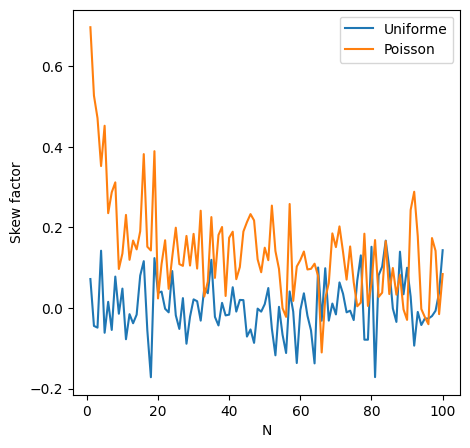

In [ ]:
n = []
fr_u = []
fr_p = []

Nmax=1000
Nlim=100

for i in range(1,Nlim+1):
  n.append(i)

  un = np.array(tlc_uniforme(Nmax, i))
  fr_u.append(ss.skew(un))

  p = np.array(tlc_poisson(Nmax, i))
  fr_p.append(ss.skew(p))

plt.figure(figsize=(5, 5))
plt.plot(n, fr_u, label='Uniforme')
plt.plot(n, fr_p, label='Poisson')
plt.legend()
plt.xlabel('N')
plt.ylabel(r"Skew factor")
plt.show()


4. Què passa si la distribució és "molt estranya"? El TLC exigeix que $N$ sigui "suficientment gran", però què significa "suficient"? Generalment, amb $N \approx 30$ n'hi ha prou, però si la distribució original té una "cua" molt llarga (molta asimetria), necessitarem un $N$ més gran.

1. Explorem això amb la distribució **Log-Normal** (`ss.lognorm.rvs(s=1, scale=np.exp(0), size=N)`).
2. Fes tres llistes de mitjanes ($N_{max} = 1000$):
   - Una agafant mostres petites: **$N = 5$**
   - Una agafant mostres mitjana: **$N = 100$**
   - Una agafant mostres grans: **$N = 1000$**

   (implementa una funció com has fet abans per la Uniforme i Poisson)
3. Fes tres gràfiques, que representin els histogrames de les mitjanes amb $N=5$, $N=100$ i $N=1000$. Aquí ja es fa molt evident que N ha de ser gran per a obtenir una distribució Normal... **[2 punts]**

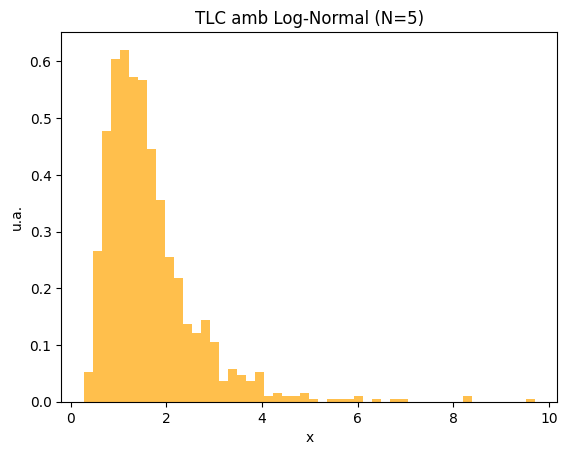

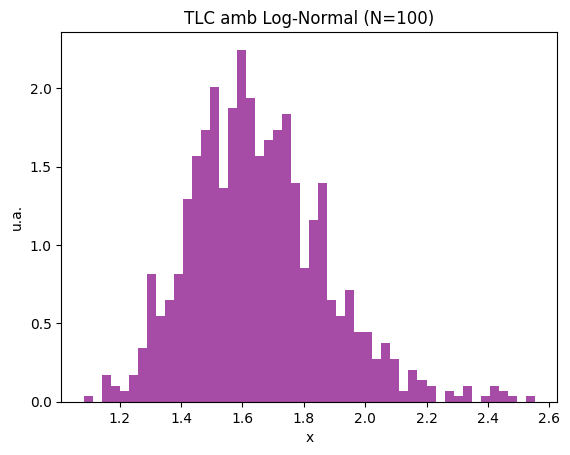

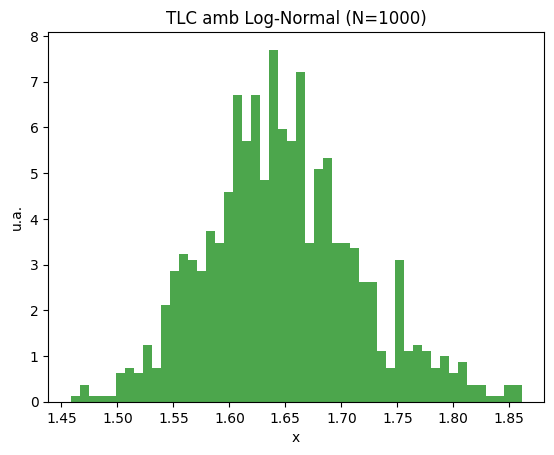

In [ ]:
Nmax = 1000

def tlc_lognormal(Nmax, N):
  mitjanes_ln = []

  for _ in range(Nmax):
    mostra = ss.lognorm.rvs(s=1, scale=np.exp(0), size=N)
    mitjanes_ln.append(np.mean(mostra))
  return mitjanes_ln

mitjanes_N5 = tlc_lognormal(Nmax, 5)
mitjanes_N100 = tlc_lognormal(Nmax, 100)
mitjanes_N1000 = tlc_lognormal(Nmax, 1000)

# Histograma per N=5
plt.hist(mitjanes_N5, bins=50, density=True, alpha=0.7, color='orange')
plt.xlabel('x')
plt.ylabel('u.a.')
plt.title("TLC amb Log-Normal (N=5)")
plt.show()
# Histograma per N=100
plt.hist(mitjanes_N100, bins=50, density=True, alpha=0.7, color='purple')
plt.xlabel('x')
plt.ylabel('u.a.')
plt.title("TLC amb Log-Normal (N=100)")
plt.show()
# Histograma per N=1000
plt.hist(mitjanes_N1000, bins=50, density=True, alpha=0.7, color='green')
plt.xlabel('x')
plt.ylabel('u.a.')
plt.title("TLC amb Log-Normal (N=1000)")
plt.show()


<font color="red">**Ampliació apartat 3**</font>

Si volem realitzar l'apartat 3 de forma més rigorosa, hauríem de repetir l'experiment múltiples vegades per a cada valor de $N$, representant gràficament el valor mitjà i l'error de l'asimetria (skew) resultants. Per aquest motiu, el codi següent executa 100 iteracions per punt, produint un resultat molt menys sensible a les fluctuacions estadístiques que heu pogut observar en executar repetides vegades el codi anterior. D'aquesta manera, podem apreciar la tendència real de l'asimetria amb molta més claredat.

**Nota:** Aquesta part, evidentment, trigaria 100 vegades més en executar que el codi de l'apartat 3!

Però es pot optimitzar de la següent forma:

*   **Generació 3D (size=(iterations, Nmax, i)):** Demanem a SciPy que generi totes les dades que necessitarem per a un $N$ concret d'una sola vegada. Per a $N=100$, això crea un bloc a la memòria de 100 x 1000 x 100 números, la qual cosa és molt ràpida a C/C++ (el llenguatge darrere de NumPy).

*   **Calculant per eixos (axis=2 i axis=1):** Fer np.mean(..., axis=2) demana a NumPy que esclafi l'última dimensió (la de mida $N$) calculant-ne la mitjana. El resultat és automàticament una matriu de 100 iteracions per 1000 mitjanes. Fer ss.skew(..., axis=1) demana que càlculi l'asimetria de les 1000 mitjanes, donant-nos automàticament una llista exacta de 100 skews (un per cada iteració).

Veiem que per a la log-normal necessitem molts valors per a que l'skew tendeixi a cero...

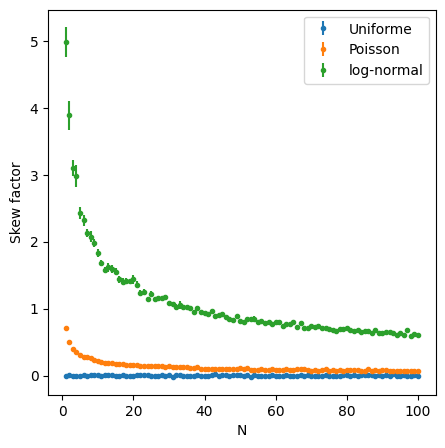

In [ ]:
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt

n = []
fr_u = []
fr_u_err = []
fr_p = []
fr_p_err = []
fr_ln = []
fr_ln_err = []

Nmax = 1000
Nlim = 100
iterations = 100

for i in range(1, Nlim + 1):
    n.append(i)

    # 1. UNIFORME
    # Generem TOTA la matriu de dades d'un sol cop: (100 iteracions, 1000 experiments, mida i)
    u_data = ss.uniform.rvs(loc=0, scale=10, size=(iterations, Nmax, i))
    u_means = np.mean(u_data, axis=2)          # Mitjana de cada mostra de mida 'i'
    u_skews = ss.skew(u_means, axis=1)         # Skew de les 1000 mitjanes per a cada iteració
    fr_u.append(np.mean(u_skews))
    fr_u_err.append(np.std(u_skews) / np.sqrt(iterations))

    # 2. POISSON
    p_data = ss.poisson.rvs(mu=2, size=(iterations, Nmax, i))
    p_means = np.mean(p_data, axis=2)
    p_skews = ss.skew(p_means, axis=1)
    fr_p.append(np.mean(p_skews))
    fr_p_err.append(np.std(p_skews) / np.sqrt(iterations))

    # 3. LOG-NORMAL
    ln_data = ss.lognorm.rvs(s=1, scale=np.exp(0), size=(iterations, Nmax, i))
    ln_means = np.mean(ln_data, axis=2)
    ln_skews = ss.skew(ln_means, axis=1)
    fr_ln.append(np.mean(ln_skews))
    fr_ln_err.append(np.std(ln_skews) / np.sqrt(iterations))

plt.figure(figsize=(5, 5))
plt.errorbar(n, fr_u, xerr=None, yerr=fr_u_err, fmt=".", label='Uniforme')
plt.errorbar(n, fr_p, xerr=None, yerr=fr_p_err, fmt=".", label='Poisson')
plt.errorbar(n, fr_ln, xerr=None, yerr=fr_ln_err, fmt=".", label='log-normal')
plt.legend()
plt.xlabel('N')
plt.ylabel('Skew factor')
plt.show()

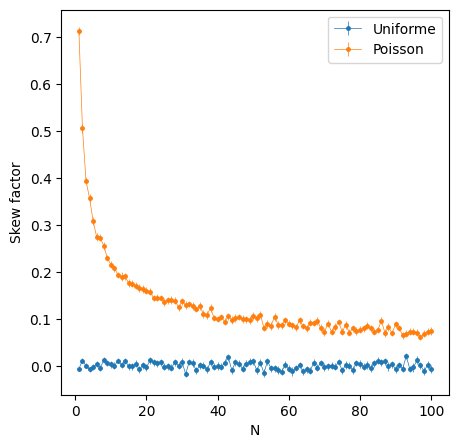

In [ ]:
# Per comparar amb apartat 3.

plt.figure(figsize=(5, 5))
plt.errorbar(n, fr_u, xerr=None, yerr=fr_u_err, marker=".", ms=5, ls="-", lw=0.5, label='Uniforme')
plt.errorbar(n, fr_p, xerr=None, yerr=fr_p_err, marker=".", ms=5, ls="-", lw=0.5, label='Poisson')
#plt.errorbar(n, fr_ln, xerr=None, yerr=fr_ln_err, fmt=".", label='log-normal')
plt.legend()
plt.xlabel('N')
plt.ylabel('Skew factor')
plt.show()